# 15_safe_hybrid_frozen_deeponet_refiner.ipynb

Безопасный гибридный вариант:

- **замороженный DeepONet v2** даёт устойчивую coarse reconstruction;
- маленький **CNN residual refiner** учится вносить только небольшую поправку;
- влияние поправки жёстко ограничено через маленький trainable коэффициент `alpha`;
- дополнительно используется штраф на величину residual-correction.

## Почему это безопаснее обычного end-to-end hybrid
В плохом гибриде coarse DeepONet деградировал, потому что учился совместно с CNN-head.
Здесь мы:
- **не трогаем** уже хороший DeepONet v2;
- учим только маленькую надстройку;
- требуем, чтобы correction была маленькой и осторожной.

## 0. Важно
`M_hom` считается через `j-Wave`, поэтому JAX запускается на **CPU**.

Refiner обучается в **PyTorch** и использует GPU, если он доступен.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu130
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "deeponet_ckpt": "/workspace/reference_points/deeponet_v2_main/deeponet_best.pt",
    "run_name": "safe_hybrid_frozen_deeponet_refiner_v1",

    "batch_size": 8,
    "epochs": 140,
    "patience": 25,
    "lr": 5e-4,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,

    "mask_half_width": 2,
    "use_residual": True,

    "branch_width": 192,
    "trunk_width": 192,
    "trunk_hidden": 256,
    "num_fourier_features": 24,
    "dropout": 0.0,

    "feat_decode_channels": 32,
    "max_refine_alpha": 0.20,
    "init_refine_alpha": 0.03,
    "lambda_residual_l2": 0.02,

    "scheduler_factor": 0.5,
    "scheduler_patience": 8,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'deeponet_ckpt': '/workspace/reference_points/deeponet_v2_main/deeponet_best.pt',
 'run_name': 'safe_hybrid_frozen_deeponet_refiner_v1',
 'batch_size': 8,
 'epochs': 140,
 'patience': 25,
 'lr': 0.0005,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'branch_width': 192,
 'trunk_width': 192,
 'trunk_hidden': 256,
 'num_fourier_features': 24,
 'dropout': 0.0,
 'feat_decode_channels': 32,
 'max_refine_alpha': 0.2,
 'init_refine_alpha': 0.03,
 'lambda_residual_l2': 0.02,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8}

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"
DEEPO_CKPT_PATH = Path(CFG["deeponet_ckpt"])

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR
assert DEEPO_CKPT_PATH.exists(), DEEPO_CKPT_PATH

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
print("deeponet checkpoint:", DEEPO_CKPT_PATH)

train: 6200
val: 1000
test: 800
deeponet checkpoint: /workspace/reference_points/deeponet_v2_main/deeponet_best.pt


In [5]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {
    "c_min": float(all_c_values.min()),
    "c_max": float(all_c_values.max()),
}

print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 1. `M_hom` through j-Wave

In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CpuDevice(id=0)]


In [7]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=1000.0,
        pml_size=16,
    )
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_224717/2997561755.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 26.080730438232422 sec


## 2. Dataset with target normalization to `[-1, 1]`

In [9]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTHybridDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {
                "path": str(self.paths[idx]),
                "x_scale": x_scale,
            },
        )

In [10]:
ds_train = USCTHybridDataset(
    train_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_val = USCTHybridDataset(
    val_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

ds_test = USCTHybridDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print(meta0)

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.7001953125}


## 3. Trunk coordinate grid

In [11]:
yy = np.linspace(-1.0, 1.0, H, dtype=np.float32)
xx = np.linspace(-1.0, 1.0, W, dtype=np.float32)
grid_y, grid_x = np.meshgrid(yy, xx, indexing="ij")
coords = np.stack([grid_y, grid_x], axis=-1).reshape(-1, 2)
coords_t = torch.from_numpy(coords)
print("coords_t:", coords_t.shape)

coords_t: torch.Size([36864, 2])


## 4. Frozen DeepONet v2 backbone

In [12]:
class BranchEncoderV2(nn.Module):
    def __init__(self, out_dim=192, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, 32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 64),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 128),
            nn.GELU(),
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(1, 192),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(192 * 2 * 32, 384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, out_dim),
        )

    def forward(self, x):
        return self.net(x)

    def forward_with_features(self, x):
        feat = self.net[:12](x)
        vec = self.net[12:](feat)
        return vec, feat

class TrunkNetV2(nn.Module):
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords

        y = coords[:, 0:1]
        x = coords[:, 1:2]

        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]

        feats = [
            coords,
            torch.sin(y_proj),
            torch.cos(y_proj),
            torch.sin(x_proj),
            torch.cos(x_proj),
        ]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))

class DeepONet2DV2(nn.Module):
    def __init__(self, branch_width=192, trunk_width=192, trunk_hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.width = int(branch_width)
        self.branch = BranchEncoderV2(out_dim=branch_width, dropout=dropout)
        self.trunk = TrunkNetV2(
            width=trunk_width,
            hidden=trunk_hidden,
            num_fourier_features=num_fourier_features,
            dropout=dropout,
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x, coords):
        b = self.branch(x)
        t = self.trunk(coords)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        out = out.view(x.shape[0], 1, H, W)
        return out

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
coords_device = coords_t.to(device)

deeponet_backbone = DeepONet2DV2(
    branch_width=CFG["branch_width"],
    trunk_width=CFG["trunk_width"],
    trunk_hidden=CFG["trunk_hidden"],
    num_fourier_features=CFG["num_fourier_features"],
    dropout=CFG["dropout"],
).to(device)

ckpt = torch.load(DEEPO_CKPT_PATH, map_location=device)
deeponet_backbone.load_state_dict(ckpt["model_state_dict"], strict=True)
deeponet_backbone.eval()

for p in deeponet_backbone.parameters():
    p.requires_grad = False

print("loaded frozen DeepONet v2")
print("best_epoch:", ckpt.get("best_epoch"))
print("best_val:", ckpt.get("best_val"))

loaded frozen DeepONet v2
best_epoch: 197
best_val: 0.011722191020846366


## 5. Safe residual refiner

In [14]:
class SmallResidualRefiner(nn.Module):
    def __init__(self, feat_in=192, feat_decode=32):
        super().__init__()
        self.feat_decoder = nn.Sequential(
            nn.Conv2d(feat_in, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, feat_decode, kernel_size=3, padding=1),
            nn.GELU(),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(1 + feat_decode, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, coarse, feat_map):
        h = self.feat_decoder(feat_map)
        h = torch.nn.functional.interpolate(
            h,
            size=coarse.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        z = torch.cat([coarse, h], dim=1)
        residual = self.refine(z)
        return residual

class SafeFrozenHybrid(nn.Module):
    def __init__(self, backbone, feat_decode=32, max_refine_alpha=0.20, init_refine_alpha=0.03):
        super().__init__()
        self.backbone = backbone
        self.refiner = SmallResidualRefiner(feat_in=192, feat_decode=feat_decode)
        self.max_refine_alpha = float(max_refine_alpha)

        init_ratio = np.clip(init_refine_alpha / max_refine_alpha, 1e-4, 1 - 1e-4)
        init_raw = math.log(init_ratio / (1.0 - init_ratio))
        self.raw_alpha = nn.Parameter(torch.tensor(init_raw, dtype=torch.float32))

    def alpha(self):
        return self.max_refine_alpha * torch.sigmoid(self.raw_alpha)

    def forward(self, x, coords, return_parts=False):
        with torch.no_grad():
            branch_vec, feat_map = self.backbone.branch.forward_with_features(x)
            trunk_vec = self.backbone.trunk(coords)
            coarse = torch.matmul(branch_vec, trunk_vec.t()) / math.sqrt(self.backbone.width) + self.backbone.bias
            coarse = coarse.view(x.shape[0], 1, H, W)

        residual = self.refiner(coarse, feat_map)
        a = self.alpha()
        pred = coarse + a * residual

        if return_parts:
            return pred, coarse, residual, a
        return pred

## 6. Metrics and helpers

In [15]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device, coords_device, scaler=None, lambda_residual_l2=0.02):
    model.train()
    total_loss = 0.0
    total_main = 0.0
    total_reg = 0.0
    total_alpha = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is None:
            pred, coarse, residual, alpha = model(x, coords_device, return_parts=True)
            loss_main = criterion(pred, c)
            loss_reg = torch.mean(residual ** 2)
            loss = loss_main + lambda_residual_l2 * loss_reg
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred, coarse, residual, alpha = model(x, coords_device, return_parts=True)
                loss_main = criterion(pred, c)
                loss_reg = torch.mean(residual ** 2)
                loss = loss_main + lambda_residual_l2 * loss_reg
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = x.shape[0]
        total_loss += float(loss.item()) * bs
        total_main += float(loss_main.item()) * bs
        total_reg += float(loss_reg.item()) * bs
        total_alpha += float(alpha.detach().item()) * bs

    n = len(loader.dataset)
    return {
        "total": total_loss / n,
        "main": total_main / n,
        "reg": total_reg / n,
        "alpha": total_alpha / n,
    }

@torch.no_grad()
def eval_loss(model, loader, criterion, device, coords_device, lambda_residual_l2=0.02):
    model.eval()
    total_loss = 0.0
    total_main = 0.0
    total_reg = 0.0
    total_alpha = 0.0

    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        pred, coarse, residual, alpha = model(x, coords_device, return_parts=True)
        loss_main = criterion(pred, c)
        loss_reg = torch.mean(residual ** 2)
        loss = loss_main + lambda_residual_l2 * loss_reg

        bs = x.shape[0]
        total_loss += float(loss.item()) * bs
        total_main += float(loss_main.item()) * bs
        total_reg += float(loss_reg.item()) * bs
        total_alpha += float(alpha.detach().item()) * bs

    n = len(loader.dataset)
    return {
        "total": total_loss / n,
        "main": total_main / n,
        "reg": total_reg / n,
        "alpha": total_alpha / n,
    }

@torch.no_grad()
def evaluate_dataset(model, dataset, device, coords_device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)

    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred, coarse, residual, alpha = model(x.unsqueeze(0).to(device), coords_device, return_parts=True)

        pred = np.clip(pred[0, 0].cpu().numpy(), -1.0, 1.0)
        coarse = np.clip(coarse[0, 0].cpu().numpy(), -1.0, 1.0)
        target = c[0].numpy()

        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        coarse_phys = denorm_c_from_minus1_1(coarse, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)

        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["coarse_rmse"] = rmse(coarse_phys, target_phys)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)

    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 7. DataLoaders

In [16]:
train_loader = DataLoader(
    ds_train,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    ds_val,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
)

print("num train batches:", len(train_loader))
print("num val batches:", len(val_loader))

num train batches: 775
num val batches: 125


## 8. Train only the refiner

In [17]:
model = SafeFrozenHybrid(
    backbone=deeponet_backbone,
    feat_decode=CFG["feat_decode_channels"],
    max_refine_alpha=CFG["max_refine_alpha"],
    init_refine_alpha=CFG["init_refine_alpha"],
).to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]
num_trainable = sum(p.numel() for p in trainable_params)
num_total = sum(p.numel() for p in model.parameters())

print("num_total params:", num_total)
print("num_trainable params:", num_trainable)

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG["scheduler_factor"],
    patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "safe_hybrid_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    train_stats = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        coords_device,
        scaler=scaler,
        lambda_residual_l2=CFG["lambda_residual_l2"],
    )
    val_stats = eval_loss(
        model,
        val_loader,
        criterion,
        device,
        coords_device,
        lambda_residual_l2=CFG["lambda_residual_l2"],
    )

    scheduler.step(val_stats["total"])

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_stats)
    val_history.append(val_stats)
    lr_history.append(current_lr)

    print(
        f"epoch {epoch:03d} | "
        f"train_total={train_stats['total']:.6f} | "
        f"val_total={val_stats['total']:.6f} | "
        f"train_main={train_stats['main']:.6f} | "
        f"val_main={val_stats['main']:.6f} | "
        f"train_reg={train_stats['reg']:.6f} | "
        f"val_reg={val_stats['reg']:.6f} | "
        f"alpha={val_stats['alpha']:.4f} | "
        f"lr={current_lr:.6e}"
    )

    if val_stats["total"] < best_val:
        best_val = val_stats["total"]
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break

t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

num_total params: 5462531
num_trainable params: 148194
epoch 001 | train_total=0.011433 | val_total=0.011618 | train_main=0.011411 | val_main=0.011528 | train_reg=0.001097 | val_reg=0.004485 | alpha=0.0507 | lr=5.000000e-04
epoch 002 | train_total=0.011239 | val_total=0.011395 | train_main=0.011066 | val_main=0.011148 | train_reg=0.008646 | val_reg=0.012351 | alpha=0.0783 | lr=5.000000e-04
epoch 003 | train_total=0.011008 | val_total=0.011185 | train_main=0.010695 | val_main=0.010828 | train_reg=0.015617 | val_reg=0.017880 | alpha=0.1029 | lr=5.000000e-04
epoch 004 | train_total=0.010798 | val_total=0.010997 | train_main=0.010400 | val_main=0.010588 | train_reg=0.019866 | val_reg=0.020437 | alpha=0.1234 | lr=5.000000e-04
epoch 005 | train_total=0.010624 | val_total=0.010831 | train_main=0.010182 | val_main=0.010395 | train_reg=0.022140 | val_reg=0.021794 | alpha=0.1396 | lr=5.000000e-04
epoch 006 | train_total=0.010488 | val_total=0.010752 | train_main=0.010022 | val_main=0.010290 | tr

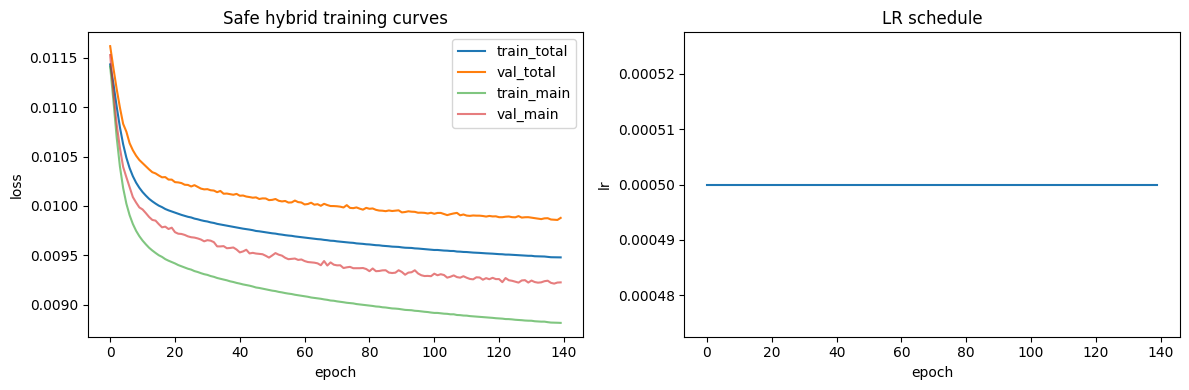

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot([x["total"] for x in train_history], label="train_total")
ax[0].plot([x["total"] for x in val_history], label="val_total")
ax[0].plot([x["main"] for x in train_history], label="train_main", alpha=0.6)
ax[0].plot([x["main"] for x in val_history], label="val_main", alpha=0.6)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Safe hybrid training curves")
ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")

plt.tight_layout()
plt.show()

## 9. Best checkpoint evaluation

In [19]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, coords_device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, coords_device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, coords_device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 83.04612951524796,
  "mse_std": 40.79103160511172,
  "rmse_mean": 8.834819590353197,
  "rmse_std": 2.2342990685005226,
  "relative_l2_mean": 0.005920621929615135,
  "relative_l2_std": 0.0014963162431878355,
  "psnr_mean": 27.12939469954011,
  "psnr_std": 2.2674251508942893,
  "coarse_rmse_mean": 10.114875776075548,
  "coarse_rmse_std": 2.3877098704734405
}

VAL SUMMARY
{
  "mse_mean": 86.96644019317627,
  "mse_std": 44.19636793358282,
  "rmse_mean": 9.028373052120209,
  "rmse_std": 2.335577064715289,
  "relative_l2_mean": 0.006050382629968226,
  "relative_l2_std": 0.0015620167445189194,
  "psnr_mean": 26.95111581131658,
  "psnr_std": 2.3010429560873806,
  "coarse_rmse_mean": 10.232013980865478,
  "coarse_rmse_std": 2.407745625985535
}

TEST SUMMARY
{
  "mse_mean": 202.6050897407532,
  "mse_std": 116.49487534391055,
  "rmse_mean": 13.61061241209507,
  "rmse_std": 4.166091587814526,
  "relative_l2_mean": 0.00912165874382481,
  "relative_l2_std": 0.0027889795

## 10. Visualization

In [20]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, coords_device, c_min, c_max):
    x, c, meta = dataset[idx]
    pred, coarse, residual, alpha = model(x.unsqueeze(0).to(device), coords_device, return_parts=True)

    pred = np.clip(pred[0, 0].cpu().numpy(), -1.0, 1.0)
    coarse = np.clip(coarse[0, 0].cpu().numpy(), -1.0, 1.0)
    residual = residual[0, 0].cpu().numpy()
    target = c[0].numpy()

    pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
    coarse_phys = denorm_c_from_minus1_1(coarse, c_min, c_max)
    target_phys = denorm_c_from_minus1_1(target, c_min, c_max)

    fig, ax = plt.subplots(1, 5, figsize=(25, 4))

    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(coarse_phys, origin="lower")
    ax[1].set_title("frozen coarse DeepONet")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(residual, origin="lower")
    ax[2].set_title(f"residual, alpha={float(alpha):.4f}")
    plt.colorbar(im2, ax=ax[2])

    im3 = ax[3].imshow(pred_phys, origin="lower")
    ax[3].set_title("safe hybrid prediction")
    plt.colorbar(im3, ax=ax[3])

    im4 = ax[4].imshow(np.abs(pred_phys - target_phys), origin="lower")
    ax[4].set_title("|pred-target|")
    plt.colorbar(im4, ax=ax[4])

    plt.tight_layout()
    plt.show()
    print(meta["path"])

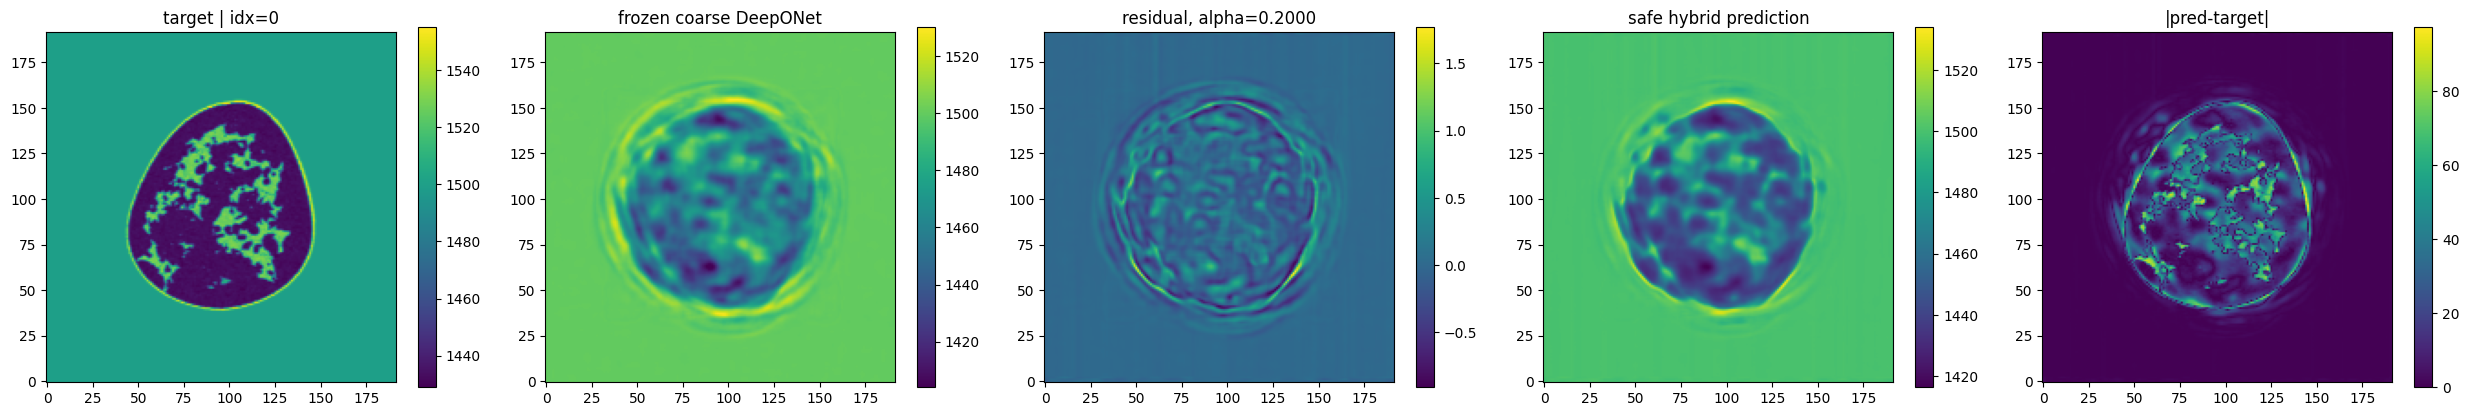

/workspace/usct_dataset_v2/test/sample_00000.npz


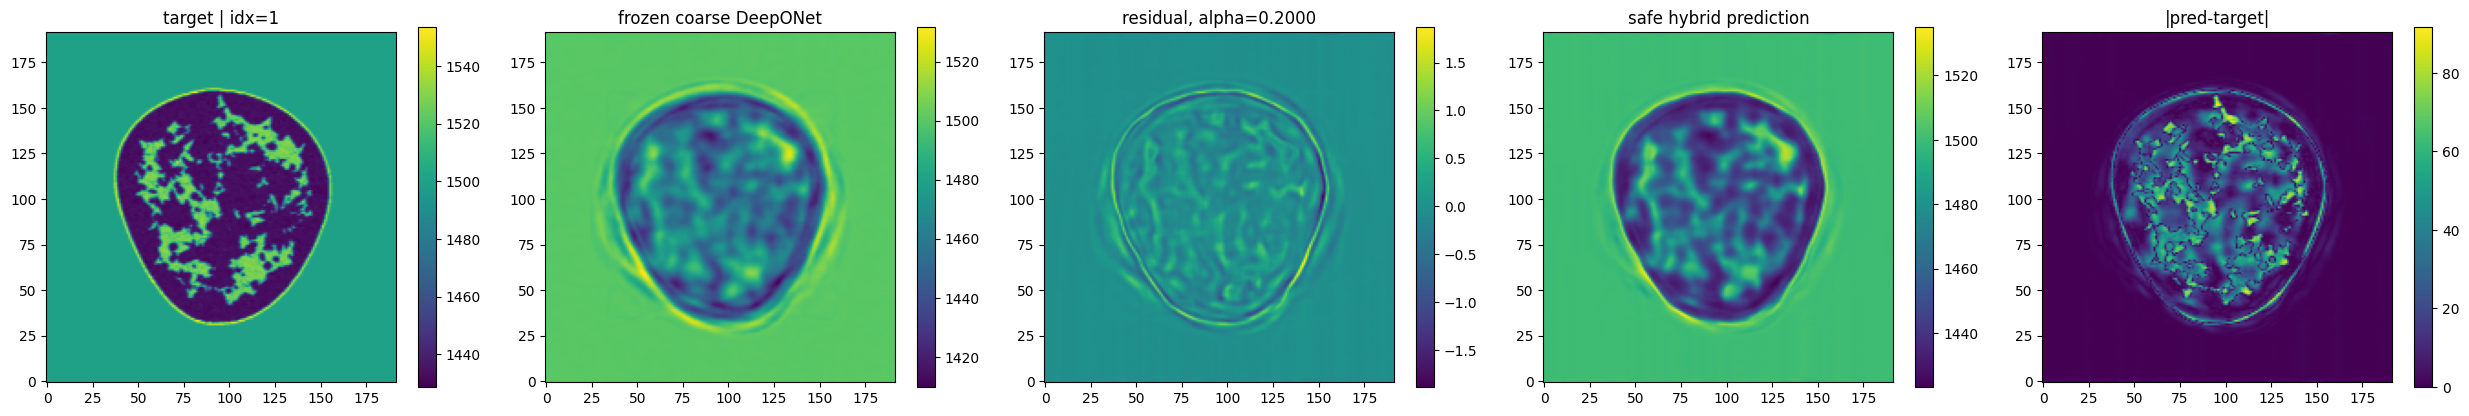

/workspace/usct_dataset_v2/test/sample_00001.npz


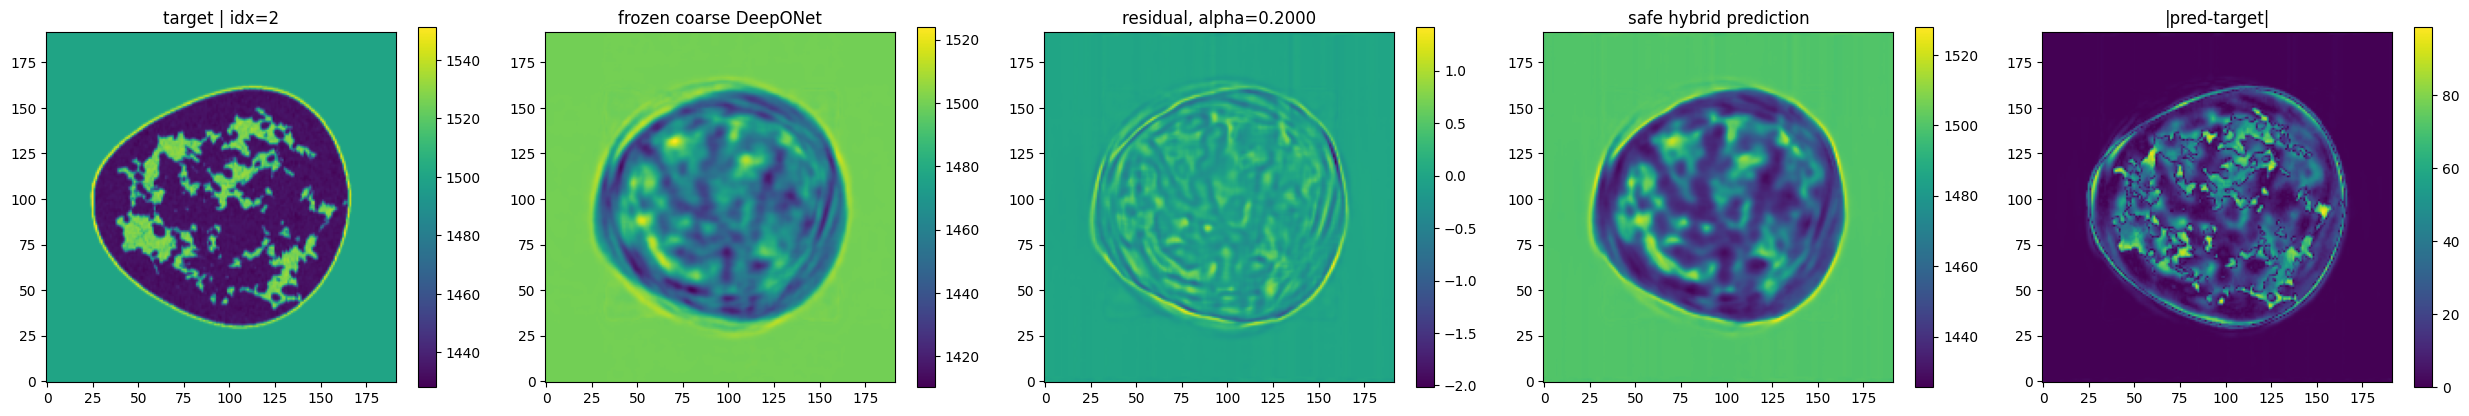

/workspace/usct_dataset_v2/test/sample_00002.npz


In [21]:
for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, coords_device, stats["c_min"], stats["c_max"])

## 11. Save artifacts

In [22]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S),
            "R": int(R),
            "H": int(H),
            "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(RUN_DIR / "train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "val_metrics.json", "w", encoding="utf-8") as f:
    json.dump(val_metrics, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_total=np.array([x["total"] for x in train_history], dtype=np.float32),
    val_total=np.array([x["total"] for x in val_history], dtype=np.float32),
    train_main=np.array([x["main"] for x in train_history], dtype=np.float32),
    val_main=np.array([x["main"] for x in val_history], dtype=np.float32),
    train_reg=np.array([x["reg"] for x in train_history], dtype=np.float32),
    val_reg=np.array([x["reg"] for x in val_history], dtype=np.float32),
    train_alpha=np.array([x["alpha"] for x in train_history], dtype=np.float32),
    val_alpha=np.array([x["alpha"] for x in val_history], dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)

print("saved to:", RUN_DIR)

saved to: /workspace/reference_points/safe_hybrid_frozen_deeponet_refiner_v1
